In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

def strassen_alg(A1, B1):
    global adds2, muls2
    adds2 = 0
    muls2 = 0

    def strassen_core(A, B):
        global adds2, muls2

        if A.shape[0] == 1:
            muls2 += 1
            return A * B

        n = A.shape[0]

        if n % 2 == 1:
            A = np.pad(A, (0, 1), mode='constant')
            B = np.pad(B, (0, 1), mode='constant')

        mid = (n + 1) // 2
        size = mid * mid

        A00 = A[:mid, :mid]
        A01 = A[:mid, mid:]
        A10 = A[mid:, :mid]
        A11 = A[mid:, mid:]

        B00 = B[:mid, :mid]
        B01 = B[:mid, mid:]
        B10 = B[mid:, :mid]
        B11 = B[mid:, mid:]

        adds2 += size  # A00 + A11
        adds2 += size  # B00 + B11
        M1 = strassen_core(A00 + A11, B00 + B11)

        adds2 += size  # A10 + A11
        M2 = strassen_core(A10 + A11, B00)

        adds2 += size  # B01 - B11
        M3 = strassen_core(A00, B01 - B11)

        adds2 += size  # B10 - B00
        M4 = strassen_core(A11, B10 - B00)

        adds2 += size  # A00 + A01
        M5 = strassen_core(A00 + A01, B11)

        adds2 += size  # A10 - A00
        adds2 += size  # B00 + B01
        M6 = strassen_core(A10 - A00, B00 + B01)

        adds2 += size  # A01 - A11
        adds2 += size  # B10 + B11
        M7 = strassen_core(A01 - A11, B10 + B11)

        result = np.zeros((2 * mid, 2 * mid), dtype=np.longdouble)

        # C00 = M1 + M4 + (M7 - M5)
        adds2 += size  # M1 + M4
        adds2 += size  # M7 - M5
        adds2 += size  # suma powyższych
        result[:mid, :mid] = (M1 + M4) + (M7 - M5)

        # C01 = M3 + M5
        adds2 += size
        result[:mid, mid:] = M3 + M5

        # C10 = M2 + M4
        adds2 += size
        result[mid:, :mid] = M2 + M4

        # C11 = (M1 - M2) + (M3 + M6)
        adds2 += size  # M1 - M2
        adds2 += size  # M3 + M6
        adds2 += size  # suma powyższych
        result[mid:, mid:] = (M1 - M2) + (M3 + M6)

        return result[:n, :n]

    res = strassen_core(A1, B1)
    return res, adds2, muls2

In [9]:
def binet_alg(A1, B1, pow, thresh):
    global adds, muls
    adds = 0
    muls = 0
    def binet_core(A, B, pow, thresh):
        global adds, muls
        if pow <= thresh:
            res, a, m = strassen_alg(A, B)
            adds += a
            muls += m
            return res
        
        if A.shape[0] == 1 or B.shape[0] == 1:
            muls += 1
            return A * B
        
        n = A.shape[0]

        if n % 2 == 1:
            A = np.pad(A, (0, 1), mode='constant')
            B = np.pad(B, (0, 1), mode='constant')

        mid = (n+1)//2

        A00 = A[:mid, :mid]
        A01 = A[:mid, mid:]
        A10 = A[mid:, :mid]
        A11 = A[mid:, mid:]

        B00 = B[:mid, : mid]
        B01 = B[:mid, mid:]
        B10 = B[mid:, :mid]
        B11 = B[mid:, mid:]

        result = np.zeros((2 * mid, 2 * mid), dtype=np.longdouble)
        adds += (mid * mid) * 4

        result[:mid, :mid] = np.add(binet_core(A00, B00, pow-1, thresh), binet_core(A01, B10, pow-1, thresh))
        result[:mid, mid:] = np.add(binet_core(A00, B01, pow-1, thresh), binet_core(A01, B11, pow-1, thresh))
        result[mid:, :mid] = np.add(binet_core(A10, B00, pow-1, thresh), binet_core(A11, B10, pow-1, thresh))
        result[mid:, mid:] = np.add(binet_core(A10, B01, pow-1, thresh), binet_core(A11, B11, pow-1, thresh))

        return result[:n, :n]
    
    res1 = binet_core(A1, B1, pow, thresh)
    return res1, adds, muls

In [ ]:
min_k, max_k = 4, 9
times_binet = np.zeros((max_k + 1, max_k + 1))
random_matrix = np.random.randint(0, 2, (2**max_k, 2**max_k))
for k in range(min_k, max_k+1):
    print(k)
    for l in range(2, k+1):
        print(l, end = " ")
        time_start = time.time()
        size = 2**k
        A = random_matrix[:size, :size]
        m1, adds1, muls1 = binet_alg(A, A, k, l)
        times_binet[k,l] = round(time.time() - time_start, 4)

4
5
6
7
8
9


In [ ]:
df1 = pd.DataFrame(times_binet)
print(df1)

     0    1         2         3         4         5         6         7  \
0  0.0  0.0    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000   
1  0.0  0.0    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000   
2  0.0  0.0    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000   
3  0.0  0.0    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000   
4  0.0  0.0    0.0121    0.0115    0.0089    0.0000    0.0000    0.0000   
5  0.0  0.0    0.0688    0.0584    0.0507    0.0448    0.0000    0.0000   
6  0.0  0.0    0.5086    0.4798    0.4034    0.3501    0.3125    0.0000   
7  0.0  0.0    4.1269    3.5593    3.0912    2.7137    2.3701    2.0685   
8  0.0  0.0   31.4668   27.7895   24.3402   21.4464   18.8118   16.4418   
9  0.0  0.0  360.8896  222.3219  194.9013  187.0100  149.5145  130.2438   

          8         9  
0    0.0000    0.0000  
1    0.0000    0.0000  
2    0.0000    0.0000  
3    0.0000    0.0000  
4    0.0000    0.0000  
5    0.0000    0.0000  
6    0

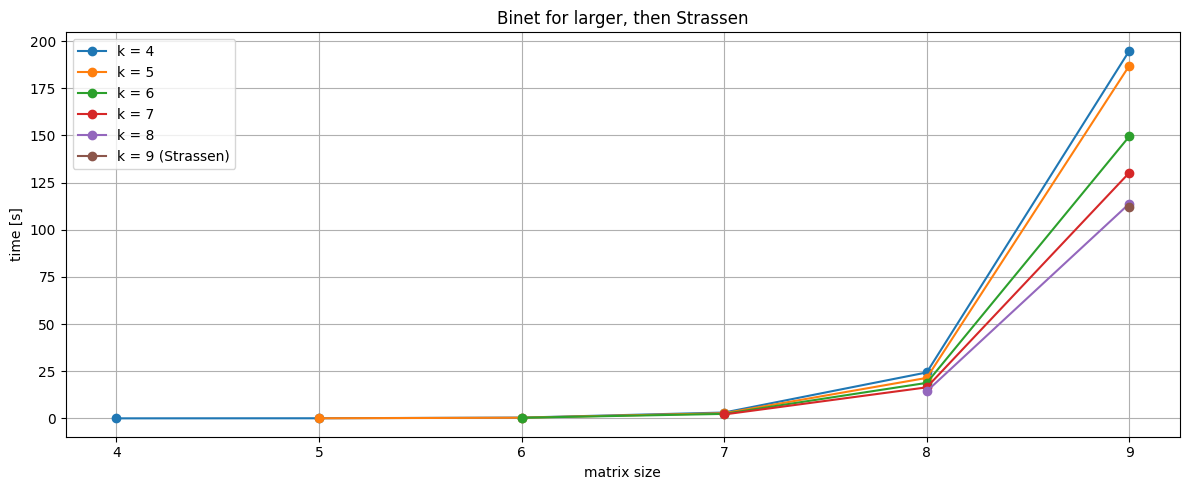

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharey=True)

for k in range(min_k, max_k+1):
    axes.plot(df1.loc[k:, k], marker='o', label=f"k = {k}{" (Strassen)" if k == max_k else ""}")

axes.set_xlabel("matrix size")
axes.set_ylabel("time [s]")
axes.set_title("Binet for larger, then Strassen")
axes.legend()
axes.grid(True)

plt.tight_layout()
plt.show()

In [24]:
min_k, max_k = 4, 8
flops_binet = np.zeros((max_k + 1, max_k + 1))
random_matrix = np.random.randint(0, 2, (2**max_k, 2**max_k))
for k in range(min_k, max_k+1):
    print(k)
    for l in range(2, k+1):
        print(l, end = " ")
        time_start = time.time()
        size = 2**k
        A = random_matrix[:size, :size]
        m2, adds_mixed, muls_mixed = binet_alg(A, A, k, l)
        flops_binet[k,l] = adds_mixed + muls_mixed
    print()

4
2 3 4 
5
2 3 4 5 
6
2 3 4 5 6 
7
2 3 4 5 6 7 
8
2 3 4 5 6 7 8 


In [25]:
df2 = pd.DataFrame(flops_binet)
print(df2)

     0    1           2           3           4           5           6  \
0  0.0  0.0         0.0         0.0         0.0         0.0         0.0   
1  0.0  0.0         0.0         0.0         0.0         0.0         0.0   
2  0.0  0.0         0.0         0.0         0.0         0.0         0.0   
3  0.0  0.0         0.0         0.0         0.0         0.0         0.0   
4  0.0  0.0     16576.0     16392.0     15271.0         0.0         0.0   
5  0.0  0.0    133632.0    132160.0    123192.0    111505.0         0.0   
6  0.0  0.0   1073152.0   1061376.0    989632.0    896136.0    798967.0   
7  0.0  0.0   8601600.0   8507392.0   7933440.0   7185472.0   6408120.0   
8  0.0  0.0  68878336.0  68124672.0  63533056.0  57549312.0  51330496.0   

            7           8  
0         0.0         0.0  
1         0.0         0.0  
2         0.0         0.0  
3         0.0         0.0  
4         0.0         0.0  
5         0.0         0.0  
6         0.0         0.0  
7   5666497.0         0.0

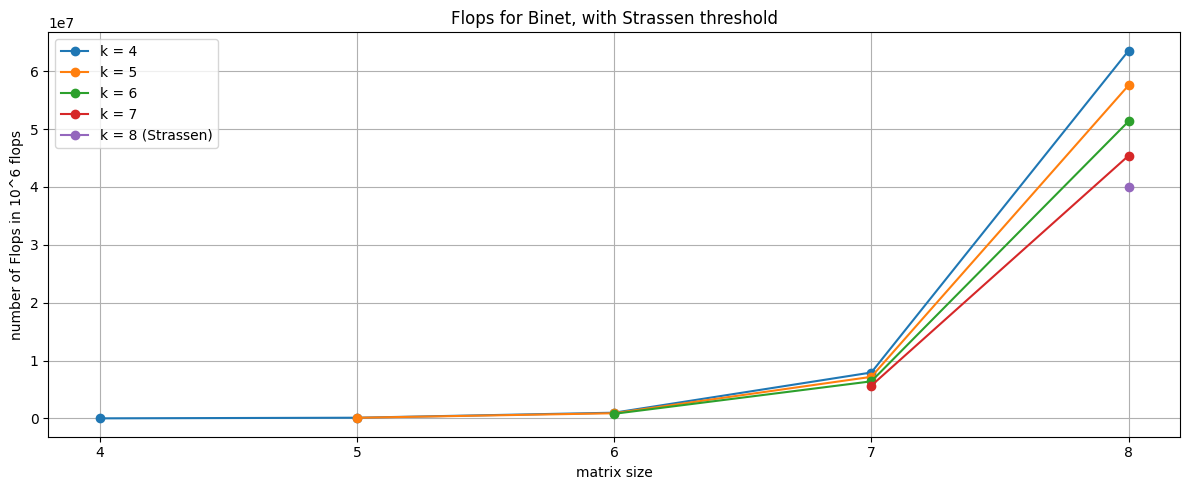

In [26]:
fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharey=True)

for k in range(min_k, max_k+1):
    axes.plot(df2.loc[k:, k], marker='o', label=f"k = {k}{" (Strassen)" if k == max_k else ""}")

axes.set_xlabel("matrix size")
axes.set_ylabel("number of Flops in 10^6 flops")
axes.set_xticks(range(min_k, max_k + 1))
axes.set_title("Flops for Binet, with Strassen threshold")
axes.legend()
axes.grid(True)

plt.tight_layout()
plt.show()